## 1. Library Imports

In [1]:
# Standard data & analysis libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")
print(f"pandas version : {pd.__version__}")
print(f"numpy version  : {np.__version__}")
print(f"yfinance version: {yf.__version__}")

Libraries loaded successfully.
pandas version : 2.2.3
numpy version  : 2.3.5
yfinance version: 1.3.0


## 2. User Parameters
Change the tickers and budget below to compare any two S&P 500 stocks.

In [2]:
# ── USER PARAMETERS ──────────────────────────────────────────────────────────
TICKER_1 = "AAPL"       # Stock A
TICKER_2 = "MSFT"       # Stock B
BUDGET   = 10_000.0     # Investment budget in USD (same amount applied to both stocks)

# Date range: 1 year ending today
END_DATE   = datetime.today()
START_DATE = END_DATE - timedelta(days=365)

print(f"Comparing: {TICKER_1} vs {TICKER_2}")
print(f"Budget   : ${BUDGET:,.2f}")
print(f"Period   : {START_DATE.strftime('%Y-%m-%d')} → {END_DATE.strftime('%Y-%m-%d')}")

Comparing: AAPL vs MSFT
Budget   : $10,000.00
Period   : 2025-04-26 → 2026-04-26


## 3. Data Acquisition
Use `yfinance` to download weekly adjusted closing prices. Using weekly frequency reduces daily noise while retaining meaningful intra-year trends.

In [6]:
def fetch_weekly_prices(ticker: str, start: str, end: str) -> pd.DataFrame:
    """
    Download weekly adjusted close prices from Yahoo Finance.
    
    Parameters
    ----------
    ticker : str   Stock ticker symbol (e.g. 'AAPL')
    start  : str   Start date in 'YYYY-MM-DD' format
    end    : str   End date in 'YYYY-MM-DD' format
    
    Returns
    -------
    pd.DataFrame   Single-column DataFrame with index=Date, column='Close'
    """
    df = yf.download(ticker, start=start, end=end,
                     interval="1wk", auto_adjust=True, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for ticker '{ticker}'. "
                         "Please verify the symbol.")
    df = df[["Close"]].dropna()
    df.columns = ["Close"]
    return df


# Fetch data for both stocks
start_str = START_DATE.strftime("%Y-%m-%d")
end_str   = END_DATE.strftime("%Y-%m-%d")

df1 = fetch_weekly_prices(TICKER_1, start_str, end_str)
df2 = fetch_weekly_prices(TICKER_2, start_str, end_str)

print(f"{TICKER_1}: {len(df1)} weekly observations  |  "
      f"${df1['Close'].iloc[0]:.2f} → ${df1['Close'].iloc[-1]:.2f}")
print(f"{TICKER_2}: {len(df2)} weekly observations  |  "
      f"${df2['Close'].iloc[0]:.2f} → ${df2['Close'].iloc[-1]:.2f}")

AAPL: 52 weekly observations  |  $204.46 → $271.06
MSFT: 52 weekly observations  |  $431.97 → $424.62


## 4. Data Cleaning & Preparation
Align both series to a common start date so the comparison window is identical for both stocks.

In [7]:
# Align to common start date (handles stocks with different first available dates)
common_start = max(df1.index[0], df2.index[0])
df1 = df1[df1.index >= common_start].copy()
df2 = df2[df2.index >= common_start].copy()

# Verify no missing values
assert df1["Close"].isna().sum() == 0, "Missing values found in Stock A"
assert df2["Close"].isna().sum() == 0, "Missing values found in Stock B"

print(f"Aligned period: {common_start.strftime('%Y-%m-%d')} → {end_str}")
print(f"Observations after alignment: {TICKER_1}={len(df1)}, {TICKER_2}={len(df2)}")
print()
print("--- First 5 rows of each dataset ---")
merged_preview = pd.DataFrame({TICKER_1: df1["Close"], TICKER_2: df2["Close"]}).head()
print(merged_preview.to_string())

Aligned period: 2025-04-28 → 2026-04-26
Observations after alignment: AAPL=52, MSFT=52

--- First 5 rows of each dataset ---
                  AAPL        MSFT
Date                              
2025-04-28  204.458893  431.972961
2025-05-05  197.668488  435.396759
2025-05-12  210.343231  450.818726
2025-05-19  194.677582  447.579987
2025-05-26  200.240662  457.701141


## 5. Descriptive Analysis
### 5a. Investment simulation metrics
Calculate how many whole shares each budget buys at the opening price, then track the value and profit/loss using the final price.

In [8]:
def investment_summary(df: pd.DataFrame, budget: float, ticker: str) -> dict:
    """
    Compute investment simulation metrics for a single stock.
    
    Key calculations:
    - price_return  = (P_final - P_initial) / P_initial  [percentage]
    - shares_bought = floor(budget / P_initial)           [whole shares only]
    - invested      = shares × P_initial                  [actual cash deployed]
    - final_value   = shares × P_final
    - pnl           = final_value - invested
    """
    p0 = float(df["Close"].iloc[0])
    pN = float(df["Close"].iloc[-1])
    
    ret      = (pN - p0) / p0 * 100
    shares   = int(budget // p0)          # floor division → whole shares
    invested = shares * p0
    final_val = shares * pN
    pnl      = final_val - invested
    
    hi = float(df["Close"].max())
    lo = float(df["Close"].min())
    
    return dict(ticker=ticker, p0=p0, pN=pN, ret=ret,
                shares=shares, invested=invested,
                final_val=final_val, pnl=pnl, hi=hi, lo=lo)


m1 = investment_summary(df1, BUDGET, TICKER_1)
m2 = investment_summary(df2, BUDGET, TICKER_2)

# Display summary table
summary_df = pd.DataFrame([m1, m2]).set_index("ticker")
summary_df.columns = ["Start $", "End $", "Return %", "Shares",
                      "Invested $", "Final Value $", "P&L $", "52wk High", "52wk Low"]
for col in ["Start $", "End $", "Invested $", "Final Value $",
            "P&L $", "52wk High", "52wk Low"]:
    summary_df[col] = summary_df[col].map("${:,.2f}".format)
summary_df["Return %"] = summary_df["Return %"].map("{:+.2f}%".format)

print("=== Investment Simulation Summary ===")
print(summary_df.to_string())

=== Investment Simulation Summary ===
        Start $    End $ Return %  Shares Invested $ Final Value $      P&L $ 52wk High 52wk Low
ticker                                                                                          
AAPL    $204.46  $271.06  +32.57%      48  $9,814.03    $13,010.88  $3,196.85   $278.59  $194.68
MSFT    $431.97  $424.62   -1.70%      23  $9,935.38     $9,766.26   $-169.12   $521.44  $356.77


### 5b. Risk metrics


In [9]:
def annualised_volatility(prices: pd.Series) -> float:
    """
    Annualised volatility from weekly log-returns.
    
    Formula: σ_annual = σ_weekly × √52
    where σ_weekly = std(ln(P_t / P_{t-1}))
    
    Using log-returns (rather than simple returns) is standard in
    quantitative finance because they are additive across time.
    """
    log_ret = np.log(prices / prices.shift(1)).dropna()
    return float(log_ret.std() * np.sqrt(52) * 100)


def max_drawdown(prices: pd.Series) -> float:
    """
    Maximum drawdown: largest percentage decline from a rolling peak.
    
    Formula: min((P_t - max(P_0..P_t)) / max(P_0..P_t))
    
    Captures the worst loss an investor would have experienced if they
    bought at the local peak and sold at the local trough.
    """
    roll_max = prices.cummax()
    drawdown = (prices - roll_max) / roll_max
    return float(drawdown.min() * 100)


vol1 = annualised_volatility(df1["Close"])
vol2 = annualised_volatility(df2["Close"])
mdd1 = max_drawdown(df1["Close"])
mdd2 = max_drawdown(df2["Close"])

risk_df = pd.DataFrame({
    "Ann. Volatility (%)": [f"{vol1:.1f}%", f"{vol2:.1f}%"],
    "Max Drawdown (%)":    [f"{mdd1:.2f}%", f"{mdd2:.2f}%"],
    "Return / Volatility": [f"{m1['ret']/vol1:.2f}", f"{m2['ret']/vol2:.2f}"]
}, index=[TICKER_1, TICKER_2])

print("=== Risk Metrics ===")
print(risk_df.to_string())
print()
print("Interpretation:")
print(f"  Higher volatility = more price fluctuation = higher risk")
print(f"  Return/Volatility = informal risk-adjusted return ratio")

=== Risk Metrics ===
     Ann. Volatility (%) Max Drawdown (%) Return / Volatility
AAPL               27.1%          -11.05%                1.20
MSFT               25.2%          -31.58%               -0.07

Interpretation:
  Higher volatility = more price fluctuation = higher risk
  Return/Volatility = informal risk-adjusted return ratio


## 6. Visualisation
### 6a. Normalised price chart
Both stocks are rebased to 100 at the start of the period, enabling a fair visual comparison regardless of their absolute price levels.

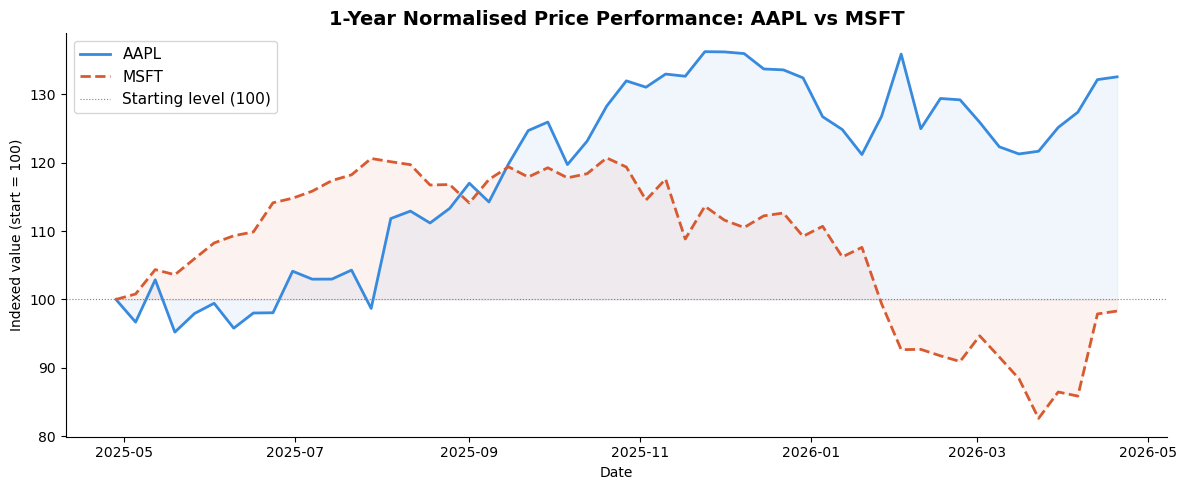

Chart saved as 'normalised_price_chart.png'


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

norm1 = (df1["Close"] / df1["Close"].iloc[0]) * 100
norm2 = (df2["Close"] / df2["Close"].iloc[0]) * 100

ax.plot(norm1.index, norm1.values, label=TICKER_1, color="#378ADD", linewidth=2)
ax.plot(norm2.index, norm2.values, label=TICKER_2, color="#D85A30",
        linewidth=2, linestyle="--")
ax.axhline(100, color="gray", linewidth=0.8, linestyle=":",
           label="Starting level (100)")

ax.fill_between(norm1.index, 100, norm1.values, alpha=0.07, color="#378ADD")
ax.fill_between(norm2.index, 100, norm2.values, alpha=0.07, color="#D85A30")

ax.set_title(f"1-Year Normalised Price Performance: {TICKER_1} vs {TICKER_2}",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Indexed value (start = 100)")
ax.set_xlabel("Date")
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("normalised_price_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as 'normalised_price_chart.png'")

### 6b. Portfolio value over time

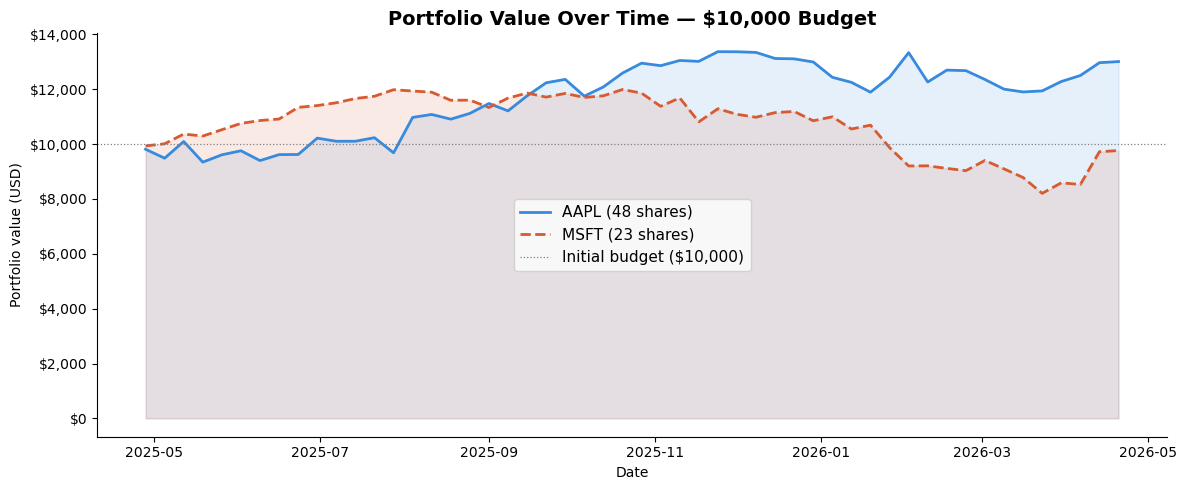

Chart saved as 'portfolio_value_chart.png'


In [11]:
fig2, ax2 = plt.subplots(figsize=(12, 5))

port1 = df1["Close"] * m1["shares"]
port2 = df2["Close"] * m2["shares"]

ax2.fill_between(port1.index, port1.values, alpha=0.12, color="#378ADD")
ax2.fill_between(port2.index, port2.values, alpha=0.12, color="#D85A30")
ax2.plot(port1.index, port1.values, label=f"{TICKER_1} ({m1['shares']} shares)",
         color="#378ADD", linewidth=2)
ax2.plot(port2.index, port2.values, label=f"{TICKER_2} ({m2['shares']} shares)",
         color="#D85A30", linewidth=2, linestyle="--")
ax2.axhline(BUDGET, color="gray", linewidth=0.9, linestyle=":",
            label=f"Initial budget (${BUDGET:,.0f})")

ax2.set_title(f"Portfolio Value Over Time — ${BUDGET:,.0f} Budget",
              fontsize=14, fontweight="bold")
ax2.set_ylabel("Portfolio value (USD)")
ax2.set_xlabel("Date")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.legend(fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("portfolio_value_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as 'portfolio_value_chart.png'")

### 6c. Return & risk comparison bar charts

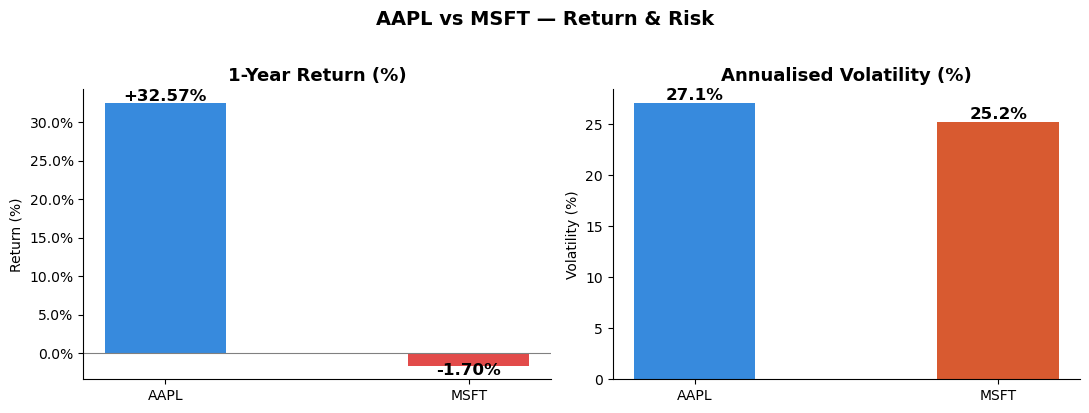

Chart saved as 'return_risk_comparison.png'


In [12]:
fig3, (ax_ret, ax_vol) = plt.subplots(1, 2, figsize=(11, 4))

# Return comparison
returns = [m1["ret"], m2["ret"]]
colors_ret = ["#378ADD" if r >= 0 else "#E24B4A" for r in returns]
bars = ax_ret.bar([TICKER_1, TICKER_2], returns, color=colors_ret,
                  width=0.4, edgecolor="none")
ax_ret.axhline(0, color="gray", linewidth=0.8)
ax_ret.set_title("1-Year Return (%)", fontsize=13, fontweight="bold")
ax_ret.set_ylabel("Return (%)")
ax_ret.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, returns):
    ax_ret.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.2 if val >= 0 else -1.2),
                f"{val:+.2f}%", ha="center", fontsize=12, fontweight="bold")
ax_ret.spines[["top", "right"]].set_visible(False)

# Volatility comparison
vols = [vol1, vol2]
ax_vol.bar([TICKER_1, TICKER_2], vols, color=["#378ADD", "#D85A30"],
           width=0.4, edgecolor="none")
ax_vol.set_title("Annualised Volatility (%)", fontsize=13, fontweight="bold")
ax_vol.set_ylabel("Volatility (%)")
for i, val in enumerate(vols):
    ax_vol.text(i, val + 0.3, f"{val:.1f}%", ha="center",
                fontsize=12, fontweight="bold")
ax_vol.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"{TICKER_1} vs {TICKER_2} — Return & Risk", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("return_risk_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as 'return_risk_comparison.png'")

## 7. Insight Generation & Interpretation

In [13]:
print("=" * 60)
print("       INVESTMENT COMPARISON SUMMARY")
print("=" * 60)
print(f"  Budget applied: ${BUDGET:,.2f}")
print(f"  Period        : {common_start.strftime('%Y-%m-%d')} → {end_str}")
print()
print(f"  {TICKER_1:<8} | Return: {m1['ret']:+.2f}%  | "
      f"P&L: ${m1['pnl']:+,.2f}  | Volatility: {vol1:.1f}%  | MDD: {mdd1:.2f}%")
print(f"  {TICKER_2:<8} | Return: {m2['ret']:+.2f}%  | "
      f"P&L: ${m2['pnl']:+,.2f}  | Volatility: {vol2:.1f}%  | MDD: {mdd2:.2f}%")
print()

winner = TICKER_1 if m1["ret"] > m2["ret"] else (TICKER_2 if m2["ret"] > m1["ret"] else None)
if winner:
    wm = m1 if winner == TICKER_1 else m2
    loser = TICKER_2 if winner == TICKER_1 else TICKER_1
    lm = m2 if winner == TICKER_1 else m1
    print(f"  WINNER: {winner} outperformed {loser} by "
          f"{abs(m1['ret'] - m2['ret']):.2f} percentage points.")
    print(f"  A ${BUDGET:,.2f} investment in {winner} would have grown to "
          f"${wm['final_val']:,.2f} (+${wm['pnl']:,.2f}).")
    print(f"  The same budget in {loser} would have ended at "
          f"${lm['final_val']:,.2f} ({lm['pnl']:+,.2f}).")
else:
    print("  RESULT: Both stocks delivered identical returns.")
print()
print(f"  Note: Higher return does not mean lower risk.")
print(f"  Risk-adjusted (return/volatility): "
      f"{TICKER_1}={m1['ret']/vol1:.2f}, {TICKER_2}={m2['ret']/vol2:.2f}")
print("=" * 60)
print()
print(f"Data source: Yahoo Finance via yfinance. Accessed {END_DATE.strftime('%d %B %Y')}.")
print("Past performance does not guarantee future results.")

       INVESTMENT COMPARISON SUMMARY
  Budget applied: $10,000.00
  Period        : 2025-04-28 → 2026-04-26

  AAPL     | Return: +32.57%  | P&L: $+3,196.85  | Volatility: 27.1%  | MDD: -11.05%
  MSFT     | Return: -1.70%  | P&L: $-169.12  | Volatility: 25.2%  | MDD: -31.58%

  WINNER: AAPL outperformed MSFT by 34.28 percentage points.
  A $10,000.00 investment in AAPL would have grown to $13,010.88 (+$3,196.85).
  The same budget in MSFT would have ended at $9,766.26 (-169.12).

  Note: Higher return does not mean lower risk.
  Risk-adjusted (return/volatility): AAPL=1.20, MSFT=-0.07

Data source: Yahoo Finance via yfinance. Accessed 26 April 2026.
Past performance does not guarantee future results.
